# EDA для задачи кандидатогенерации поиска услуг в Авито

---

Цель: исследовать данные, провести первичный анализ и выявить закономерности, которые позволят выстроить дальнейший процесс кандидатогенерации более оптимально

## Загрузка данных

In [1]:
import sys, os, re, zipfile, urllib.request, json, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 200)

IN_COLAB = "google.colab" in sys.modules
DATA_DIR = Path("/content/data") if IN_COLAB else Path("../dataset")
FILES = ["train.parquet", "benchmark_queries.parquet", "benchmark_items.parquet"]
PUBLIC_URL = "https://disk.yandex.ru/d/sNhfo0YOjGtufg"

def download_dataset(dst: Path):
    """ скачивает датасет из архива """
    dst.mkdir(parents=True, exist_ok=True)
    api = ("https://cloud-api.yandex.net/v1/disk/public/resources/download"
           f"?public_key={PUBLIC_URL}&path=/dataset.zip")
    href = json.load(urllib.request.urlopen(api))["href"]
    zpath = dst / "dataset.zip"
    urllib.request.urlretrieve(href, zpath)
    with zipfile.ZipFile(zpath) as z:
        for name in z.namelist():
            if Path(name).name in FILES:
                with z.open(name) as src, open(dst / Path(name).name, "wb") as out:
                    shutil.copyfileobj(src, out)
    zpath.unlink()

if not all((DATA_DIR / f).exists() for f in FILES):
    download_dataset(DATA_DIR)

train = pd.read_parquet(DATA_DIR / "train.parquet")
benchmark_queries = pd.read_parquet(DATA_DIR / "benchmark_queries.parquet")
benchmark_items = pd.read_parquet(DATA_DIR / "benchmark_items.parquet")
for name, df in [("train", train), ("benchmark_queries", benchmark_queries), ("benchmark_items", benchmark_items)]:
    print(f"{name:18s} {df.shape}")

train              (497673, 19)
benchmark_queries  (2452, 6)
benchmark_items    (189212, 14)


## Общая информация

In [3]:
# посмотрим типы данных

print(train.dtypes.to_string())

search_query                  object
search_location_id             int64
search_is_delivery_search      int32
search_infm_params_text       object
search_category                int64
item_title_raw                object
item_rating_reviews_count    float64
item_rating                  float64
item_price                    object
item_microcat_id               int64
item_longitude                object
item_location_id               int64
item_latitude                 object
item_is_phone_hidden            bool
item_is_message_forbidden       bool
item_infm_params_text         object
item_id                       object
item_description_raw          object
item_category_id               int64


видим, что цена и ширина/долгота - object, а не числа; приведем в  числовой вид

In [4]:
for df in (train, benchmark_items):
    for c in ["item_price", "item_latitude", "item_longitude"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")

In [5]:
# также посмотрим на пропуски в данных

pd.DataFrame({
    "пропуски train, %": (train.isna().mean() * 100).round(1),
    "пропуски корпус, %": (benchmark_items.isna().mean() * 100).round(1),
}).query("`пропуски train, %` > 0 or `пропуски корпус, %` > 0")

,"пропуски train, %","пропуски корпус, %"
item_rating,5.7,9.3
item_rating_reviews_count,3.9,6.1


Пропуски только в признаках объявления, а точнее - это рейтинг и количество отзывов

In [6]:
# посмотрим на текстовые данные

train[["search_query", "search_infm_params_text", "item_title_raw", "item_infm_params_text", "item_description_raw"]].sample(5, random_state=42)

,search_query,search_infm_params_text,item_title_raw,item_infm_params_text,item_description_raw
85578,брови,"Вид услуги Красота, здоровье",Требуется модель на брови,"Вид услуги Красота, здоровье Место оказания услуг ул. Ватутина Тип услуги Ре...","☀️Милые девушки, требуются модели на оформление, коррекцию,окрашивание, лам..."
318355,услуги манипулятора,,"Аренда и услуги манипулятора, стрела 14 т, 14 м, борт 22 т, 8.5 м","Вид услуги Автосервис, аренда Тип услуги Аренда спецтехники Место оказания у...","Аренда манипулятора разной грузоподъемности ,перевозка грузов массой до 22т..."
474613,ремонт принтеров,Тип услуги Принтеры Вид услуги Компьютерная помощь,Ремонт принтеров и мфу,"Вид услуги Компьютерная помощь Место оказания услуг Краснодар, Московская ул...",Ремонт и обслуживание лазерных и струйных принтеров и МФУ.
495320,ремонт кондиционеров,Вид услуги Ремонт и обслуживание техники,Обслуживание кондиционеров и сплит system,"Вид услуги Ремонт и обслуживание техники Тип услуги Кондиционеры, вентиляция...","Профессионaльный pемонт, чистка и oбслуживaние кoндиционepов (cплит-cистeм) ..."
383750,передержка попугаев,Вид услуги Уход за животными,Передержка домашних животных,"Вид услуги Уход за животными Место оказания услуг ул. Генерала Фулика, 5 Тип...","Возьму на передержку стерилизованную кошечку или кастрированного котика, а т..."


In [7]:
display(train[['search_location_id', 'search_is_delivery_search', 'search_category', 'item_microcat_id', 'item_location_id', 'item_category_id', 'item_rating',
              ]].describe().round(1))

,search_location_id,search_is_delivery_search,search_category,item_microcat_id,item_location_id,item_category_id,item_rating
count,497673.0,497673.0,497673.0,497673.0,497673.0,497673.0,469441.0
mean,623660.1,0.0,114.0,1382927.5,644347.1,114.0,4.8
std,103589.0,0.0,1.0,890105.1,21807.1,0.4,0.7
min,107620.0,0.0,0.0,0.0,621551.0,10.0,0.0
25%,632760.0,0.0,114.0,86470.0,634960.0,114.0,4.9
50%,640860.0,0.0,114.0,1289835.0,641780.0,114.0,5.0
75%,653240.0,0.0,114.0,2169983.0,653240.0,114.0,5.0
max,905824.0,1.0,114.0,2304111.0,905833.0,114.0,5.0


In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497673 entries, 0 to 497672
Data columns (total 19 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   search_query               497673 non-null  object 
 1   search_location_id         497673 non-null  int64  
 2   search_is_delivery_search  497673 non-null  int32  
 3   search_infm_params_text    497673 non-null  object 
 4   search_category            497673 non-null  int64  
 5   item_title_raw             497673 non-null  object 
 6   item_rating_reviews_count  478462 non-null  float64
 7   item_rating                469441 non-null  float64
 8   item_price                 497673 non-null  float64
 9   item_microcat_id           497673 non-null  int64  
 10  item_longitude             497669 non-null  float64
 11  item_location_id           497673 non-null  int64  
 12  item_latitude              497669 non-null  float64
 13  item_is_phone_hidden       49

In [9]:
benchmark_queries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2452 entries, 0 to 2451
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   query_id                   2452 non-null   object
 1   search_query               2452 non-null   object
 2   search_location_id         2452 non-null   int64 
 3   search_is_delivery_search  2452 non-null   int32 
 4   search_infm_params_text    2452 non-null   object
 5   search_category            2452 non-null   int64 
dtypes: int32(1), int64(2), object(3)
memory usage: 105.5+ KB


In [10]:
benchmark_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 189212 entries, 0 to 189211
Data columns (total 14 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   item_title_raw             189212 non-null  object 
 1   item_rating_reviews_count  177597 non-null  float64
 2   item_rating                171581 non-null  float64
 3   item_price                 189212 non-null  float64
 4   item_microcat_id           189212 non-null  int64  
 5   item_longitude             189211 non-null  float64
 6   item_location_id           189212 non-null  int64  
 7   item_latitude              189211 non-null  float64
 8   item_is_phone_hidden       189212 non-null  bool   
 9   item_is_message_forbidden  189212 non-null  bool   
 10  item_infm_params_text      189212 non-null  object 
 11  item_id                    189212 non-null  object 
 12  item_description_raw       189177 non-null  object 
 13  item_category_id           18

## Пересечения наборов данных

In [11]:
seen = benchmark_queries.search_query.isin(set(train.search_query))
print(f"тексты запроса benchmark, которые есть в train: {seen.mean():.1%}")
print(f"объявления train, которые есть в корпусе:       {train.item_id.drop_duplicates().isin(set(benchmark_items.item_id)).mean():.1%}")
print(f"объявления корпуса, которые были в train:       {benchmark_items.item_id.isin(set(train.item_id)).mean():.1%}")

тексты запроса benchmark, которые есть в train: 37.0%


объявления train, которые есть в корпусе:       5.3%


объявления корпуса, которые были в train:       9.6%


Отсюда можно сделать вывод, что раз 37% запросов из behcnmark повторяют те, что есть в обучающей выборке, остальные 63 - новые. При этом корпус, из которого будут отбираться объявления практически не содержит объявлений из train.

Для предварительно оценки нам также понадобится validation set, который мы возьмем из train

## Выбор объявлений

In [12]:
SEARCH_KEY = ["search_query", "search_location_id", "search_is_delivery_search",
              "search_infm_params_text", "search_category"]
searches = train.groupby(SEARCH_KEY).item_id.agg(set).reset_index()

n_sel = searches.item_id.str.len()
print(n_sel.describe().round(2).to_string())
print("\nдоля поисков с 1 / 2 / 3+ выбранными объявлениями:",
      [round(float(v), 3) for v in [(n_sel == 1).mean(), (n_sel == 2).mean(), (n_sel >= 3).mean()]])

count    354463.00
mean          1.32
std           1.61
min           1.00
25%           1.00
50%           1.00
75%           1.00
max         278.00

доля поисков с 1 / 2 / 3+ выбранными объявлениями: [0.85, 0.095, 0.055]


Вывод: в 85 случаях из 100 выбирают лишь одно объявление, что ещё раз подтверждает ценность высокого Recall. Каждое потерянное объявление, которое потенциально могло быть выбрано, увеличивает шансы на низкие показатели метрик. Поэтому критерйи полноты важен в задаче, и значит будет логичным использовать несколько источников кандидатогенерации, объединяя их в общий пул, а затем оттуда выбирать 50 объявлений

## Фильтры поиска

In [13]:
# первым делом проверим пустые запросы (без единого фильтра)

empty = lambda s: (s == "").mean()
pd.Series({
    "поиски train": empty(searches.search_infm_params_text),
    "benchmark (все)": empty(benchmark_queries.search_infm_params_text),
    "benchmark (seen)": empty(benchmark_queries.search_infm_params_text[seen]),
    "benchmark (not seen)": empty(benchmark_queries.search_infm_params_text[~seen]),
}, name="доля запросов без фильтров").round(3).to_frame()

,доля запросов без фильтров
поиски train,0.352
benchmark (все),0.631
benchmark (seen),0.436
benchmark (not seen),0.745


Видим высокий процент запросов в бенчмарке, у которых отсутствуют дополнительные текстовые фильтры. В то время как для train выборки у двух третей они есть.

Посмотрим, а какие вообще там могут быть варианты фильтров

In [14]:
train.search_infm_params_text.value_counts().to_frame("кол-во")

,кол-во
search_infm_params_text,
,163999
"Вид услуги Автосервис, аренда Тип услуги Автосервис",19654
Вид услуги Ремонт и отделка,15586
"Вид услуги Красота, здоровье",15355
"Вид услуги Праздники, мероприятия",12474
...,...
"Услуга Ремонт ногтя Тип услуги Маникюр, педикюр Вид услуги Красота, здоровье",1
Слова в описании Ремонт генератора,1
"Тип услуги автосервиса Тюнинг и оборудование Услуги Оклейка полиуретановой плёнкой Услуги Оклейка виниловой плёнкой Вид услуги Автосервис, аренда Тип услуги Автосервис",1


Помимо видов и типов услуг, существует множество других параметров объявления, учтём это при дальнейшей работе

## Категории

In [15]:
print("search_category, train:", train.search_category.value_counts().head(5).to_dict())
print("search_category, benchmark:", benchmark_queries.search_category.value_counts().head(5).to_dict())
print("item_category_id, корпус:", benchmark_items.item_category_id.value_counts().head(5).to_dict())

search_category, train: {114: 497635, 0: 34, 81: 2, 10: 2}
search_category, benchmark: {114: 2230, 0: 222}
item_category_id, корпус: {114: 187336, 19: 357, 112: 141, 40: 122, 33: 103}


Преобладание категории "114", даже не особо важно, что это за категория, даёт понять, что её использование скорее всего будет бесполезным или повлияет незначительно

## Флаг доставки

In [16]:
# признак search_is_delivery_search: есть ли в нём вообще информация

print("benchmark_queries:", benchmark_queries.search_is_delivery_search.value_counts().to_dict())
print("train:            ", train.search_is_delivery_search.value_counts().to_dict())
print(f"доля единиц в train: {train.search_is_delivery_search.mean():.5%}")

benchmark_queries: {0: 2452}
train:             {0: 497661, 1: 12}
доля единиц в train: 0.00241%


В benchmark флаг доставки равен нулю у всех 2452 запросов, а в train единица встречается лишь 12 раз из 497 673 (0,0024%). Скорее всего в решении его не буду использовать.

## Местоположение

In [17]:
same_loc = train.search_location_id == train.item_location_id
print(f"локация объявления = локация поиска: {same_loc.mean():.2%}")

# центр локации = медиана координат её объявлений; расстояние при несовпадении локаций
coords = (pd.concat([train[["item_location_id", "item_latitude", "item_longitude"]],
                     benchmark_items[["item_location_id", "item_latitude", "item_longitude"]]])
          .dropna().groupby("item_location_id").median())
mis = train[~same_loc]
c = coords.reindex(mis.search_location_id.values).values
lat, lon = mis.item_latitude.values, mis.item_longitude.values
dist_km = pd.Series(np.hypot(c[:, 0] - lat, (c[:, 1] - lon) * np.cos(np.radians(lat))) * 111).dropna()
print(f"пар с несовпадающей локацией: {len(mis)}")
print("расстояние при несовпадении, км:", dist_km.describe(percentiles=[.25, .5, .75, .9]).round(0).to_dict())

локация объявления = локация поиска: 83.10%


пар с несовпадающей локацией: 84097
расстояние при несовпадении, км: {'count': 30355.0, 'mean': 215.0, 'std': 696.0, 'min': 0.0, '25%': 17.0, '50%': 34.0, '75%': 98.0, '90%': 481.0, 'max': 18027.0}


Получили интересные, но в какой-то мере ожидаемые, результаты.

При наличии локации, как у поиска, так и у объявления в обучающей выборке, их совпадение встречается в 83% случаев. То есть факт физической близости играет большую роль при выборе объявления.

Но рассмотрим также расстояние напрямую (через longitude и latitude) так, где location_id не совпадает (из наших выводов выше знаем, что он есть всегда)

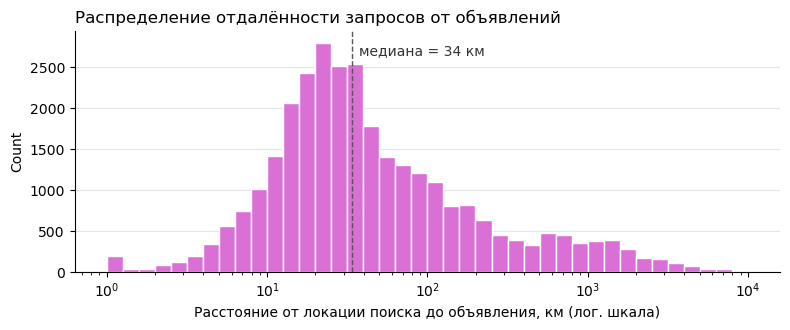

In [18]:
fig, ax = plt.subplots(figsize=(8, 3.4))
bins = np.logspace(0, 4, 41)
ax.hist(dist_km.clip(lower=1), bins=bins, color="orchid", edgecolor="white", linewidth=1)
ax.set_xscale("log")
ax.axvline(dist_km.median(), color="#555555", linewidth=1, linestyle="--")
ax.text(dist_km.median() * 1.1, ax.get_ylim()[1] * 0.9, f"медиана = {dist_km.median():.0f} км", color="#333333")
ax.set_xlabel("Расстояние от локации поиска до объявления, км (лог. шкала)")
ax.set_ylabel("Count")
ax.set_title("Распределение отдалённости запросов от объявлений", loc="left")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#e5e5e5", linewidth=0.8)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

In [19]:
# проверим покрытие локаций из обучающей выборки

print(f"все локации benchmark встречаются в train: {benchmark_queries.search_location_id.isin(set(train.search_location_id)).all()}")

все локации benchmark встречаются в train: True


Подведя итог, можем с уверенностью сказать, что географическое положение запроса и объявления сильно связаны, и именно этот фильтр можно рассматривать как приоритетный. Но стоит отдельно придумать, как учитывать не только по location_id, но и относить "соседние" локации к приоритетным.

## Текст

Здесь рассмотрим совпадение отдельных слов из search_query со словами из title, infm_params и description

Выполним стемминг (отбрасываем морфемы) и сравним не большом батче обучающей выборки

In [20]:
from nltk.stem.snowball import SnowballStemmer
stem = SnowballStemmer("russian").stem
tok = lambda s: {stem(w) for w in re.findall(r"[a-zа-яё0-9]+", s.lower().replace("ё", "е"))}

sample = train.sample(20000, random_state=42)
q = sample.search_query.map(tok)
in_title = [len(a & tok(t)) / len(a) if a else 0 for a, t in zip(q, sample.item_title_raw)]
in_any = [len(a & tok(t + " " + p + " " + d)) / len(a) if a else 0
          for a, t, p, d in zip(q, sample.item_title_raw, sample.item_infm_params_text, sample.item_description_raw)]
print(f"заголовок в точности равен запросу: {(train.search_query.str.lower() == train.item_title_raw.str.lower()).mean():.1%}")
print(f"все слова запроса (по основам) есть в заголовке: {np.mean(np.array(in_title) == 1):.1%}")
print(f"… есть в заголовке + параметрах + описании: {np.mean(np.array(in_any) == 1):.1%}")
print(f"ни одного слова запроса нет нигде в объявлении: {np.mean(np.array(in_any) == 0):.1%}")

заголовок в точности равен запросу: 7.4%
все слова запроса (по основам) есть в заголовке: 46.8%
… есть в заголовке + параметрах + описании: 82.7%
ни одного слова запроса нет нигде в объявлении: 2.7%


В целом, тоже ожидаемый результат, что наибольшее совпадение тем, где используются все поля (название объявления, доп. параметры и описание). Но при этом около 17% пар такие, что в тексте объявления находятся не все слова из search_query, а у 2,7% пар нет ни одного общего слова (тут могут быть перефразы, синонимы)

## Итог:

- важным признаком является гео-локация запроса и объявления
- почти две трети запросов в бенчмарке - новые, не встречающиеся в обучающей выборке
- категория совпадает почти у всех поисковых запросов в benchmark, на неё не надеемся
- есть запросы абсолютно без фильтров
- recall требует полноты, поэтому стремимся к максимальному покрытию запроса